<h4> Install libraries

In [23]:
#!pip install pandas numpy scikit-learn matplotlib seaborn nltk -q

<h4>  Imports

In [2]:
import re, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
print('Libraries ready')

Libraries ready


<h4> Define Classifiers & TF-IDF Variants -> 
SVM,
K-NN (k=5),
K-NN (k=3)

In [3]:
CLASSIFIERS = {
    'SVM':        LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5, metric='cosine', algorithm='brute'),
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3, metric='cosine', algorithm='brute'),
}

# TF-IDF variants (paper Figure 2 + N-gram extension)
# sublinear_tf=True implements Eq.1: TF = 1 + log10(f_{t,d})
TFIDF_VARIANTS = {
    'Unigram (1,1)': TfidfVectorizer(ngram_range=(1,1), sublinear_tf=True, max_features=10000, min_df=2, max_df=0.95),
    'Bigram (2,2)': TfidfVectorizer(ngram_range=(2,2), sublinear_tf=True, max_features=10000, min_df=2, max_df=0.95),
    'Uni+Bigram (1,2)': TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, max_features=15000, min_df=2, max_df=0.95),
}
print('Classifiers:', list(CLASSIFIERS.keys()))
print('TF-IDF variants:', list(TFIDF_VARIANTS.keys()))

Classifiers: ['SVM', 'k-NN (k=5)', 'k-NN (k=3)']
TF-IDF variants: ['Unigram (1,1)', 'Bigram (2,2)', 'Uni+Bigram (1,2)']


<h4> Load Dataset

In [4]:
df = pd.read_csv('cyberbullying_tweets.csv')

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")
df = df.dropna(subset=['tweet_text', 'cyberbullying_type'])
print(f"After dropping nulls: {len(df)} rows")

print(f'Shape: {df.shape}')
print('\nClass distribution:')
print(df['cyberbullying_type'].value_counts())
df.head(5)


Missing values: 0
After dropping nulls: 47692 rows
Shape: (47692, 2)

Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


<h4> Converts 6 categories into Binary Labels -> output: Bully (1) and Normal (0)

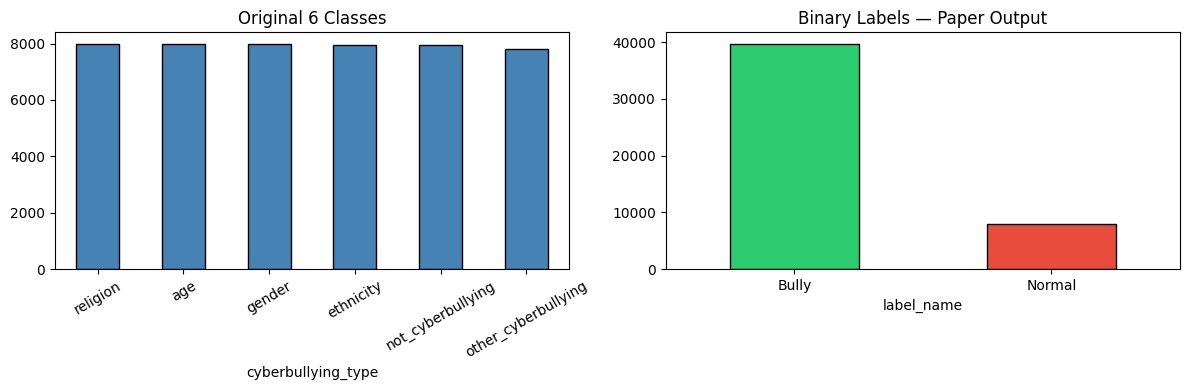

Normal: 7945  |  Bully: 39747


In [5]:
df['label'] = df['cyberbullying_type'].apply(
    lambda x: 0 if x == 'not_cyberbullying' else 1)
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Bully'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['cyberbullying_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Original 6 Classes')
axes[0].tick_params(axis='x', rotation=30)

df['label_name'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black'
)
axes[1].set_title('Binary Labels — Paper Output')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print(f"Normal: {(df['label']==0).sum()}  |  Bully: {(df['label']==1).sum()}")

<h4> Pre-processing
1. Clean → Tokenize → Stop Word Removal → Stemming

[Note -> Paper uses Sastrawi stemmer for Bahasa Indonesia. 
We use PorterStemmer — the English equivalent.]

In [6]:
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['rt','via','http','https','amp','get','got'])
stemmer = PorterStemmer()

def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)            # remove @mentions
    text = re.sub(r'#\w+', '', text)            # remove #hashtags
    text = re.sub(r'&[a-z]+;', '', text)        # HTML entities
    text = re.sub(r'[^a-z\s]', '', text)        # letters only
    return re.sub(r'\s+', ' ', text).strip()

def preprocess(text):
    text   = clean_text(text)                                       # Clean
    tokens = word_tokenize(text)                                    # Tokenize
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]  # Stopwords
    tokens = [stemmer.stem(t) for t in tokens]                     # Stem
    return ' '.join(tokens)

print('Processing tweets (~1 min)...')
df['processed_text'] = df['tweet_text'].apply(preprocess)
df = df[df['processed_text'].str.strip() != ''].reset_index(drop=True)

for _, row in df.sample(3, random_state=1).iterrows():
    print(f'Label    : {row.label_name}')
    print(f'Raw      : {row.tweet_text[:80]}')
    print(f'Processed: {row.processed_text[:80]}')
    print()
print(f' {len(df)} samples ready')

print("\nPRE-PROCESSING EXAMPLES:")
print(f"{'Original Tweet':<50} {'Processed'}")
print("-" * 80)
for _, row in df.sample(5, random_state=42).iterrows():
    print(f"{str(row['tweet_text'])[:48]:<50} {row['processed_text'][:30]}")

Processing tweets (~1 min)...
Label    : Bully
Raw      : in the philippines we have, a president who makes rape jokes and considers being
Processed: philippin presid make rape joke consid gay diseas xenophob racist peopl everywhe

Label    : Bully
Raw      : Miley Cyrus rode a blow-up dick and told a date rape joke at a London gay club. 
Processed: miley cyru rode blowup dick told date rape joke london gay club typic friday nig

Label    : Bully
Raw      : YOU ALL ACT LIKE DUMB NIGGERS,EVEN YOU WHITE FAGGOTS.PLEASE KEEP THE FUCK AWAY F
Processed: act like dumb niggerseven white faggotspleas keep fuck away boil point reach

 47083 samples ready

PRE-PROCESSING EXAMPLES:
Original Tweet                                     Processed
--------------------------------------------------------------------------------
No she was the bullied girl in high school with    bulli girl high school hygien 
@ldstarr18 @AC360 Islam is worse than the Nazi p   islam wors nazi parti ever
@Mariana_gmez Sin a

<h4> Train / Test Split (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 37666  |  Test: 9417


#### TF-IDF + Classification
Paper equations:
- **Eq.1** TF = `1 + log₁₀(f_{t,d})` if f > 0, else 0
- **Eq.2** IDF = `log(D / df_j)`
- **Eq.3** W = `TF × IDF`

In [8]:
results    = []
fit_models = {}

for vec_name, vectorizer in TFIDF_VARIANTS.items():
    X_tr = vectorizer.fit_transform(X_train)   
    X_te = vectorizer.transform(X_test)

    print(f'\n[{vec_name}] — {X_tr.shape[1]} features')
    print(f"  {'Classifier':<15} {'Acc%':>7} {'Prec%':>7} {'Rec%':>7} {'F1%':>7}")
    print(f"  {'-'*15} {'-----':>7} {'-----':>7} {'----':>7} {'---':>7}")

    for clf_name, clf_template in CLASSIFIERS.items():
        clf = copy.deepcopy(clf_template)
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)

        acc  = accuracy_score (y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1   = f1_score(y_test, y_pred, average='binary', zero_division=0)

        print(f"  {clf_name:<15} {acc*100:>6.2f}% {prec*100:>6.2f}% {rec*100:>6.2f}% {f1*100:>6.2f}%")

        results.append({
            'TF-IDF Variant': vec_name, 'Classifier': clf_name,
            'Accuracy': round(acc*100,2), 'Precision': round(prec*100,2),
            'Recall':   round(rec*100,2), 'F1-Score':  round(f1*100,2),
            '_cm': confusion_matrix(y_test, y_pred), '_y_pred': y_pred
        })
        fit_models[f'{vec_name}|{clf_name}'] = (vectorizer, clf)


[Unigram (1,1)] — 10000 features
  Classifier         Acc%   Prec%    Rec%     F1%
  ---------------   -----   -----    ----     ---
  SVM              85.15%  89.41%  93.28%  91.30%
  k-NN (k=5)       83.08%  88.59%  91.55%  90.04%
  k-NN (k=3)       80.61%  88.54%  88.21%  88.38%

[Bigram (2,2)] — 10000 features
  Classifier         Acc%   Prec%    Rec%     F1%
  ---------------   -----   -----    ----     ---
  SVM              83.67%  85.42%  97.01%  90.85%
  k-NN (k=5)       82.61%  85.03%  96.11%  90.23%
  k-NN (k=3)       80.86%  84.99%  93.63%  89.10%

[Uni+Bigram (1,2)] — 15000 features
  Classifier         Acc%   Prec%    Rec%     F1%
  ---------------   -----   -----    ----     ---
  SVM              85.13%  89.49%  93.15%  91.28%
  k-NN (k=5)       82.67%  88.73%  90.79%  89.75%
  k-NN (k=3)       79.66%  88.52%  86.94%  87.72%


<h4> 5-Fold Cross Validation

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

print("5-FOLD CROSS VALIDATION")
print("=" * 55)
print("(More reliable than a single train/test split)\n")

cv_results = []

for vec_name, vectorizer in TFIDF_VARIANTS.items():
    for clf_name, clf_template in CLASSIFIERS.items():
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                ngram_range=vectorizer.ngram_range,
                sublinear_tf=True,
                max_features=vectorizer.max_features,
                min_df=2, max_df=0.95
            )),
            ('clf', copy.deepcopy(clf_template))
        ])

        # cv=5 means 5 folds; scoring='f1' uses binary F1
        scores = cross_val_score(
            pipe, df['processed_text'], df['label'],
            cv=5, scoring='f1', n_jobs=-1
        )

        mean_f1 = round(scores.mean() * 100, 2)
        std_f1  = round(scores.std()  * 100, 2)

        print(f"  {vec_name} + {clf_name}")
        print(f"    CV F1 = {mean_f1}% ± {std_f1}%")
        print(f"    Single-split F1 = {next(r['F1-Score'] for r in results if r['TF-IDF Variant']==vec_name and r['Classifier']==clf_name)}%\n")

        cv_results.append({
            'TF-IDF Variant': vec_name,
            'Classifier':     clf_name,
            'CV F1 Mean':     mean_f1,
            'CV F1 Std':      std_f1
        })

5-FOLD CROSS VALIDATION
(More reliable than a single train/test split)

  Unigram (1,1) + SVM
    CV F1 = 78.79% ± 15.91%
    Single-split F1 = 91.3%

  Unigram (1,1) + k-NN (k=5)
    CV F1 = 81.98% ± 9.8%
    Single-split F1 = 90.04%

  Unigram (1,1) + k-NN (k=3)
    CV F1 = 80.41% ± 11.02%
    Single-split F1 = 88.38%

  Bigram (2,2) + SVM
    CV F1 = 79.65% ± 16.85%
    Single-split F1 = 90.85%

  Bigram (2,2) + k-NN (k=5)
    CV F1 = 88.57% ± 1.1%
    Single-split F1 = 90.23%

  Bigram (2,2) + k-NN (k=3)
    CV F1 = 86.98% ± 1.3%
    Single-split F1 = 89.1%

  Uni+Bigram (1,2) + SVM
    CV F1 = 78.76% ± 16.22%
    Single-split F1 = 91.28%

  Uni+Bigram (1,2) + k-NN (k=5)
    CV F1 = 80.09% ± 11.31%
    Single-split F1 = 89.75%

  Uni+Bigram (1,2) + k-NN (k=3)
    CV F1 = 78.35% ± 11.74%
    Single-split F1 = 87.72%



<h4> Results Table

In [10]:
cols = ['TF-IDF Variant','Classifier','Accuracy','Precision','Recall','F1-Score']
df_r = pd.DataFrame(results)[cols].sort_values('F1-Score', ascending=False)

display(df_r.style.background_gradient(subset=['Accuracy','F1-Score'], cmap='YlOrRd'))

best = df_r.iloc[0]
print(f"\n★  Best: {best['TF-IDF Variant']} + {best['Classifier']}")
print(f"   Acc={best['Accuracy']}%  Prec={best['Precision']}%  Rec={best['Recall']}%  F1={best['F1-Score']}%")

,TF-IDF Variant,Classifier,Accuracy,Precision,Recall,F1-Score
0,"Unigram (1,1)",SVM,85.150000,89.410000,93.280000,91.300000
6,"Uni+Bigram (1,2)",SVM,85.130000,89.490000,93.150000,91.280000
3,"Bigram (2,2)",SVM,83.670000,85.420000,97.010000,90.850000
4,"Bigram (2,2)",k-NN (k=5),82.610000,85.030000,96.110000,90.230000
1,"Unigram (1,1)",k-NN (k=5),83.080000,88.590000,91.550000,90.040000
7,"Uni+Bigram (1,2)",k-NN (k=5),82.670000,88.730000,90.790000,89.750000
5,"Bigram (2,2)",k-NN (k=3),80.860000,84.990000,93.630000,89.100000
2,"Unigram (1,1)",k-NN (k=3),80.610000,88.540000,88.210000,88.380000
8,"Uni+Bigram (1,2)",k-NN (k=3),79.660000,88.520000,86.940000,87.720000



★  Best: Unigram (1,1) + SVM
   Acc=85.15%  Prec=89.41%  Rec=93.28%  F1=91.3%


<h4> Visualisations

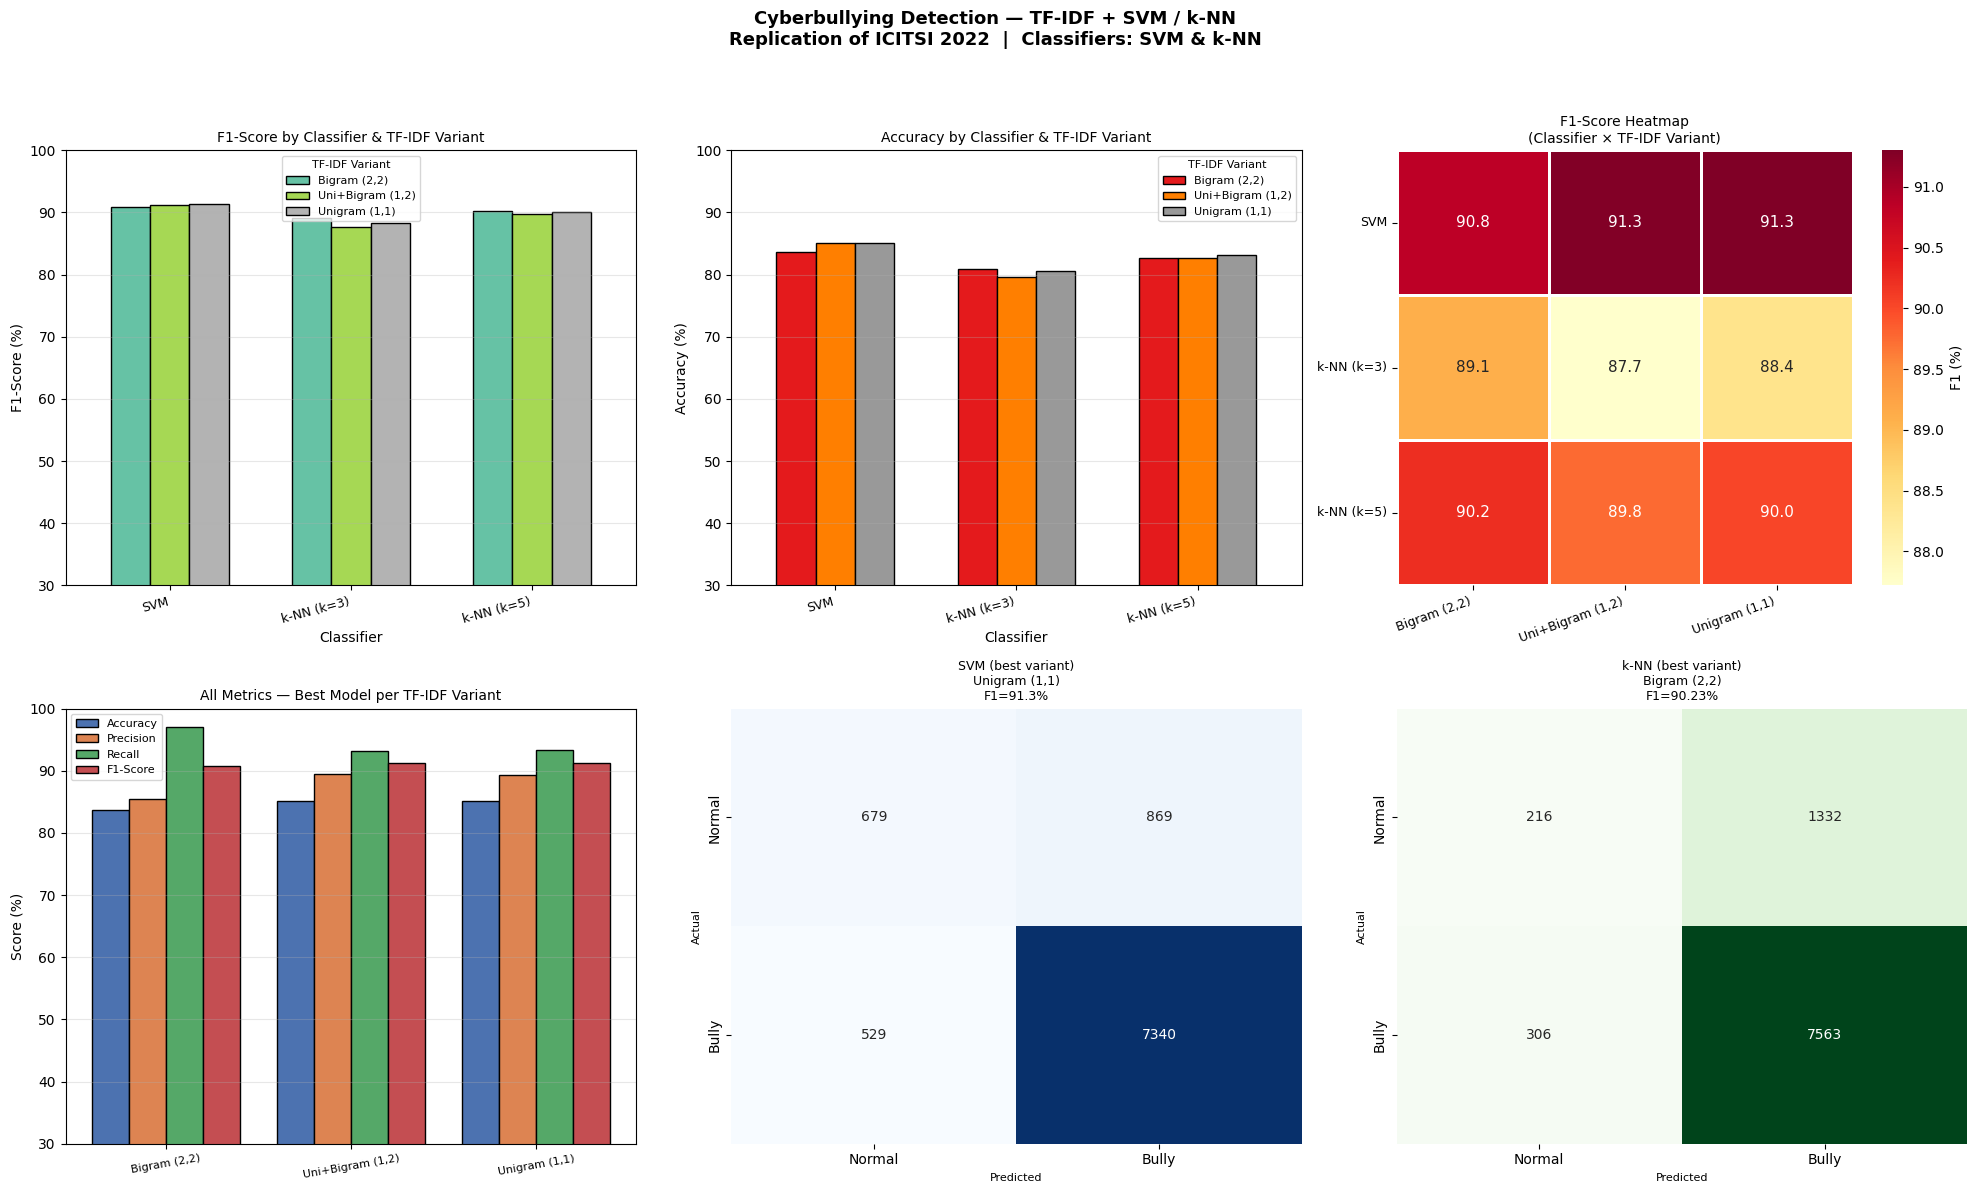

In [11]:
df_plot = pd.DataFrame(results)
fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'Cyberbullying Detection — TF-IDF + SVM / k-NN\nReplication of ICITSI 2022  |  Classifiers: SVM & k-NN',
    fontsize=13, fontweight='bold', y=0.99
)

# Panel 1: F1 grouped bar
ax1 = fig.add_subplot(2,3,1)
df_plot.pivot_table(index='Classifier', columns='TF-IDF Variant', values='F1-Score') \
       .plot(kind='bar', ax=ax1, colormap='Set2', edgecolor='black', width=0.65)
ax1.set_title('F1-Score by Classifier & TF-IDF Variant', fontsize=10)
ax1.set_ylabel('F1-Score (%)')
ax1.set_ylim(30,100)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax1.legend(fontsize=8, title='TF-IDF Variant', title_fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Accuracy grouped bar
ax2 = fig.add_subplot(2,3,2)
df_plot.pivot_table(index='Classifier', columns='TF-IDF Variant', values='Accuracy') \
       .plot(kind='bar', ax=ax2, colormap='Set1', edgecolor='black', width=0.65)
ax2.set_title('Accuracy by Classifier & TF-IDF Variant', fontsize=10)
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(30,100)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax2.legend(fontsize=8, title='TF-IDF Variant', title_fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# Panel 3: F1 heatmap
ax3 = fig.add_subplot(2,3,3)
heat = df_plot.pivot_table(index='Classifier', columns='TF-IDF Variant', values='F1-Score')
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.8, ax=ax3,
            cbar_kws={'label':'F1 (%)'}, annot_kws={'size':11})
ax3.set_title('F1-Score Heatmap\n(Classifier × TF-IDF Variant)', fontsize=10)
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=9)

# Panel 4: All 4 metrics for best model per variant
ax4 = fig.add_subplot(2,3,4)
metrics = ['Accuracy','Precision','Recall','F1-Score']
colors  = ['#4C72B0','#DD8452','#55A868','#C44E52']
best_rows = df_plot.sort_values('F1-Score', ascending=False).groupby('TF-IDF Variant').first().reset_index()
x = np.arange(len(best_rows))
w = 0.2
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax4.bar(x + i*w, best_rows[m], w, label=m, color=c, edgecolor='black')
ax4.set_xticks(x + 1.5*w)
ax4.set_xticklabels(best_rows['TF-IDF Variant'], fontsize=8, rotation=10)
ax4.set_ylim(30,100)
ax4.set_ylabel('Score (%)')
ax4.set_title('All Metrics — Best Model per TF-IDF Variant', fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

# Panels 5 & 6: Confusion matrices (best SVM vs best k-NN)
svm_res  = [r for r in results if r['Classifier']=='SVM']
knn_res  = [r for r in results if 'k-NN' in r['Classifier']]
best_svm = sorted(svm_res, key=lambda r: r['F1-Score'], reverse=True)[0]
best_knn = sorted(knn_res, key=lambda r: r['F1-Score'], reverse=True)[0]

for pos, (res, cmap, title) in enumerate([
    (best_svm, 'Blues',  'SVM (best variant)'),
    (best_knn, 'Greens', 'k-NN (best variant)'),
], start=5):
    ax = fig.add_subplot(2,3,pos)
    sns.heatmap(res['_cm'], annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal','Bully'], yticklabels=['Normal','Bully'], cbar=False)
    ax.set_title(f"{title}\n{res['TF-IDF Variant']}\nF1={res['F1-Score']}%", fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('cyberbullying_results.png', dpi=150, bbox_inches='tight')
plt.show()

<h4> Detailed Classification Reports

In [12]:
svm_res = [r for r in results if r['Classifier']=='SVM']
knn_res = [r for r in results if 'k-NN' in r['Classifier']]
best_svm = sorted(svm_res, key=lambda r: r['F1-Score'], reverse=True)[0]
best_knn = sorted(knn_res, key=lambda r: r['F1-Score'], reverse=True)[0]

for res, header in [(best_svm,'BEST SVM'), (best_knn,'BEST k-NN')]:
    print('='*55)
    print(f"{header} — {res['TF-IDF Variant']} + {res['Classifier']}")
    print('='*55)
    print(classification_report(y_test, res['_y_pred'],
                                 target_names=['Normal (0)','Bully (1)']))

BEST SVM — Unigram (1,1) + SVM
              precision    recall  f1-score   support

  Normal (0)       0.56      0.44      0.49      1548
   Bully (1)       0.89      0.93      0.91      7869

    accuracy                           0.85      9417
   macro avg       0.73      0.69      0.70      9417
weighted avg       0.84      0.85      0.84      9417

BEST k-NN — Bigram (2,2) + k-NN (k=5)
              precision    recall  f1-score   support

  Normal (0)       0.41      0.14      0.21      1548
   Bully (1)       0.85      0.96      0.90      7869

    accuracy                           0.83      9417
   macro avg       0.63      0.55      0.56      9417
weighted avg       0.78      0.83      0.79      9417



<h4> Demo: Predict New Text

In [13]:
from IPython.display import display, HTML

label_map  = {0: '✅ Normal', 1: '🚨 Bully'}
demo_texts = [
    'You are so stupid and ugly, nobody likes you',
    'Have a great day! Hope you are doing well.',
    'I hate all people like you, go away loser',
    'Thanks for this informative video!',
    'Kill yourself you worthless piece of trash',
    'Great work everyone, proud of this team!',
    'Hi there!'
]

all_combos = [
    ('Unigram (1,1)', 'SVM'),
    ('Unigram (1,1)', 'k-NN (k=5)'),
    ('Unigram (1,1)', 'k-NN (k=3)'),
    ('Bigram (2,2)', 'SVM'),
    ('Bigram (2,2)', 'k-NN (k=5)'),
    ('Bigram (2,2)','k-NN (k=3)'),
    ('Uni+Bigram (1,2)','SVM'),
    ('Uni+Bigram (1,2)', 'k-NN (k=5)'),
    ('Uni+Bigram (1,2)', 'k-NN (k=3)'),
]

for vec_name, clf_name in all_combos:
    key = f'{vec_name}|{clf_name}'
    vec, clf = fit_models[key]
    f1_val = next(r['F1-Score'] for r in results
                    if r['TF-IDF Variant']==vec_name and r['Classifier']==clf_name)

    out  = f"\n{'='*55}\n"
    out += f"  MODEL : {vec_name} + {clf_name}\n"
    out += f"  F1    : {f1_val}%\n"
    out += f"{'='*55}\n"
    for text in demo_texts:
        proc = preprocess(text)
        pred = clf.predict(vec.transform([proc]))[0]
        out += f"  Input : {text}\n"
        out += f"  Label : {label_map[pred]}\n\n"

    display(HTML(f"<pre>{out}</pre>"))